In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
print("Libraries loaded!")

Libraries loaded!


In [2]:
# 1. Load the data, skipping the second descriptive row
income_df = pd.read_csv('data\ACSST5Y2024.S1901-Data.csv', skiprows=[1])

# 2. Keep only the columns we need: GEO_ID and Median Income
# Column S1901_C01_012E = Estimate!!Households!!Median income
income_df = income_df[['GEO_ID', 'S1901_C01_012E']].copy()

# 3. Rename for clarity
income_df.columns = ['geo_id', 'median_income']

# 4. Extract the 5-digit Zip Code from GEO_ID (e.g., '8600000US10001' -> '10001')
income_df['zip_code'] = income_df['geo_id'].str.split('US').str[-1]

# 5. Convert income to numeric (removes non-number strings like "-" or "250,000+")
income_df['median_income'] = pd.to_numeric(income_df['median_income'], errors='coerce')

# Drop rows where we don't have income data
income_df = income_df.dropna(subset=['median_income'])

print(f"Loaded income data for {len(income_df)} Zip Codes.")
income_df.head()

Loaded income data for 1617 Zip Codes.


,geo_id,median_income,zip_code
0,860Z200US06390,98125.0,06390
1,860Z200US10001,129852.0,10001
2,860Z200US10002,48386.0,10002
3,860Z200US10003,154262.0,10003
5,860Z200US10005,190233.0,10005


In [3]:
# Load the tree data (You can start with 2nd parameter nrows=10000 to test, then remove nrows later)
trees_df = pd.read_csv('data/2015_Street_Tree_Census_-_Tree_Data_20260315.csv')

# 1. Filter to only 'Alive' trees (we can't measure the health of a stump)
trees_df = trees_df[trees_df['status'] == 'Alive']

# 2. Keep only the relevant columns
trees_df = trees_df[['tree_id', 'health', 'postcode', 'spc_common', 'borough']]

# 3. Ensure Zip Code (postcode) is a string to match the income data
trees_df['postcode'] = trees_df['postcode'].astype(str)

print(f"Loaded {len(trees_df)} living trees.")
trees_df.head()

Loaded 652173 living trees.


,tree_id,health,postcode,spc_common,borough
0,180683,Fair,11375,red maple,Queens
1,200540,Fair,11357,pin oak,Queens
2,204026,Good,11211,honeylocust,Brooklyn
3,204337,Good,11211,honeylocust,Brooklyn
4,189565,Good,11215,American linden,Brooklyn


In [4]:
# 1. Count how many trees are in each Zip Code
tree_counts = trees_df.groupby('postcode')['tree_id'].count().reset_index()
tree_counts.columns = ['zip_code', 'tree_count']

# 2. Calculate "Health Score"
# We map Good=3, Fair=2, Poor=1 to turn categories into a math average
health_map = {'Good': 3, 'Fair': 2, 'Poor': 1}
trees_df['health_numeric'] = trees_df['health'].map(health_map)

avg_health = trees_df.groupby('postcode')['health_numeric'].mean().reset_index()
avg_health.columns = ['zip_code', 'avg_health_score']

# 3. Merge tree stats together
tree_stats = pd.merge(tree_counts, avg_health, on='zip_code')

# 4. FINAL MERGE: Link Tree Stats with Income!
final_df = pd.merge(tree_stats, income_df, on='zip_code')

print("Final Combined Dataset Created!")
final_df.head()

Final Combined Dataset Created!


,zip_code,tree_count,avg_health_score,geo_id,median_income
0,10001,850,2.809412,860Z200US10001,129852.0
1,10002,2158,2.714087,860Z200US10002,48386.0
2,10003,1943,2.709213,860Z200US10003,154262.0
3,10005,130,2.346154,860Z200US10005,190233.0
4,10006,48,2.875000,860Z200US10006,190170.0


In [5]:
# Z-Score filter for outliers
from scipy import stats
import numpy as np

# Remove Zip Codes with very few trees (e.g., less than 50)
filtered_df = final_df[final_df['tree_count'] > 50].copy()

# Filter out extreme income outliers (more than 3 standard deviations away)
z_scores = np.abs(stats.zscore(filtered_df['median_income']))
clean_df = filtered_df[z_scores < 3]

print(f"Removed {len(final_df) - len(clean_df)} outlier Zip Codes.")

Removed 4 outlier Zip Codes.


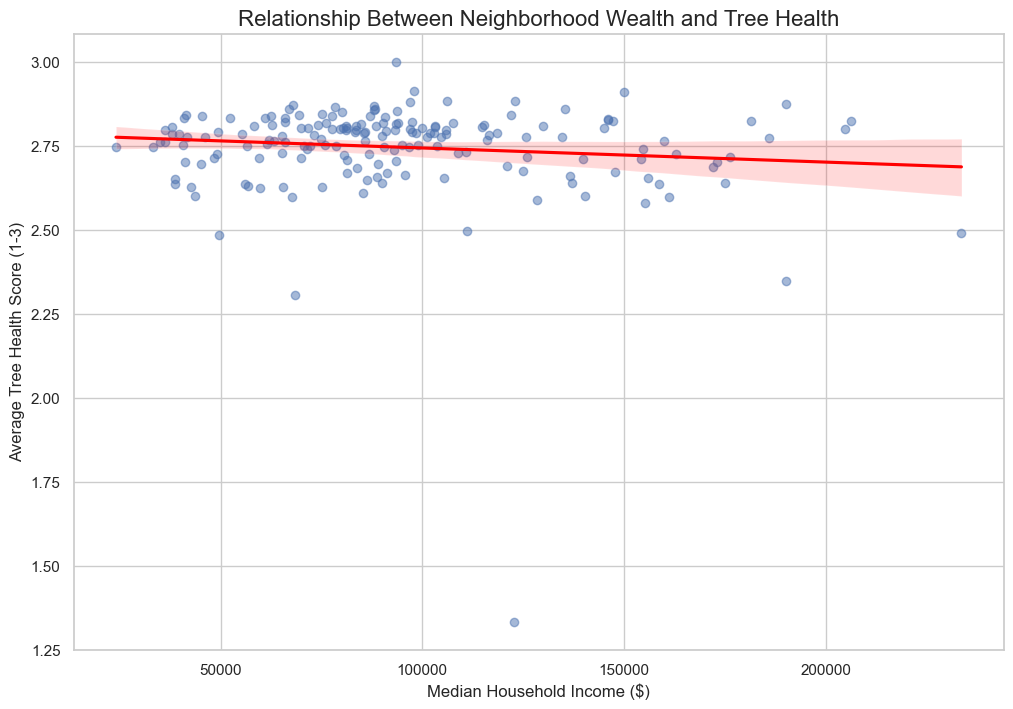

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot with a regression line
plt.figure(figsize=(12, 8))
sns.regplot(data=final_df, x='median_income', y='avg_health_score', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relationship Between Neighborhood Wealth and Tree Health', fontsize=16)
plt.xlabel('Median Household Income ($)', fontsize=12)
plt.ylabel('Average Tree Health Score (1-3)', fontsize=12)

plt.show()

In [7]:
# Calculate the correlation matrix
correlation = final_df['median_income'].corr(final_df['avg_health_score'])

print(f"The Correlation between Income and Tree Health is: {correlation:.2f}")

if correlation > 0.3:
    print("Result: There is a moderate to strong positive relationship!")
elif correlation > 0:
    print("Result: There is a weak positive relationship.")
else:
    print("Result: There is no positive relationship found yet.")

The Correlation between Income and Tree Health is: -0.12
Result: There is no positive relationship found yet.


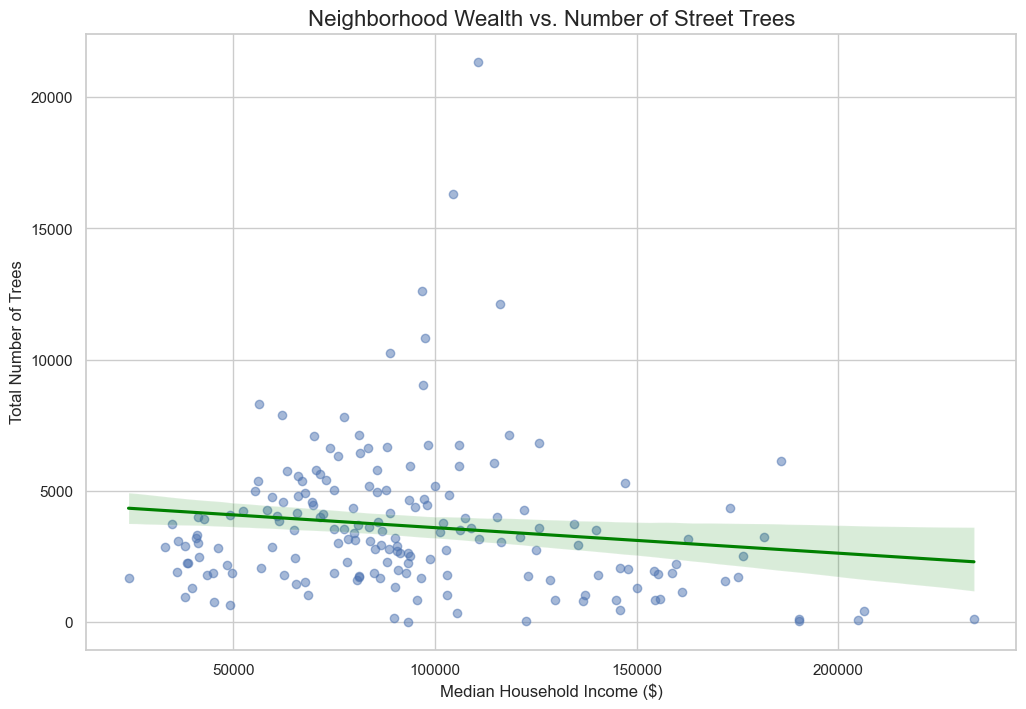

In [8]:
# Scatter plot for Income vs. Total Tree Count
plt.figure(figsize=(12, 8))
sns.regplot(data=final_df, x='median_income', y='tree_count', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'green'})

plt.title('Neighborhood Wealth vs. Number of Street Trees', fontsize=16)
plt.xlabel('Median Household Income ($)', fontsize=12)
plt.ylabel('Total Number of Trees', fontsize=12)

plt.show()

<Axes: xlabel='median_income', ylabel='percent_good'>

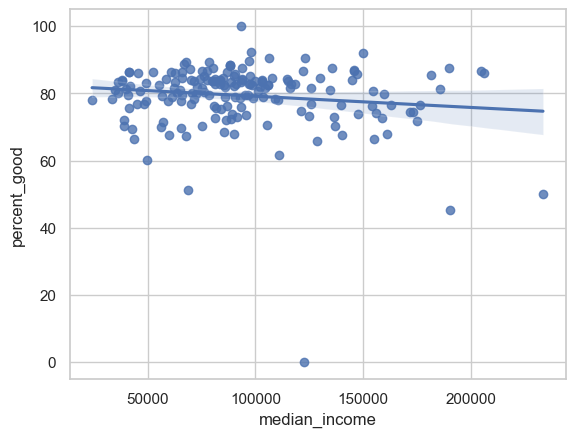

In [10]:
# Go back to trees_df and calculate % of 'Good' trees
health_counts = trees_df.groupby(['postcode', 'health']).size().unstack(fill_value=0)
health_counts['total'] = health_counts.sum(axis=1)
health_counts['percent_good'] = (health_counts['Good'] / health_counts['total']) * 100

# Merge this back into your final_df
final_df = final_df.merge(health_counts[['percent_good']], left_on='zip_code', right_index=True)

# Now plot Income vs Percent Good
sns.regplot(data=final_df, x='median_income', y='percent_good')

In [ ]:
# We haven't found a correlations so far...
# Analyzing the whole city at once mixes concrete jungles (Manhattan) with garden boroughs (Queens). Lets try splitting the scatter plot by Borough.

# --- STEP 1: ADD BOROUGH INFO ---
# Create the lookup from the original trees_df 
zip_to_borough = trees_df.groupby('postcode')['borough'].first().reset_index()
zip_to_borough.columns = ['zip_code', 'borough']

# Merge it into final_df
if 'borough' not in final_df.columns:
    final_df = final_df.merge(zip_to_borough, on='zip_code', how='left')

# --- STEP 2: CREATE THE CLEAN VERSION ---
# We remove Zip Codes with < 20 trees and income outliers
from scipy import stats
import numpy as np

# 1. Filter by tree count
clean_df = final_df[final_df['tree_count'] > 20].copy()

# 2. Filter by Income (removing top/bottom 1% or using Z-score)
z_scores = np.abs(stats.zscore(clean_df['median_income']))
clean_df = clean_df[z_scores < 3]

print(f"Cleaned data ready. Using {len(clean_df)} neighborhoods out of {len(final_df)}.")

# --- STEP 3: BOROUGH CORRELATION ---
print("\n--- Correlation by Borough (Wealth vs. % Good Health) ---")
for borough in clean_df['borough'].dropna().unique():
    subset = clean_df[clean_df['borough'] == borough]
    # We need at least a few data points to calculate correlation
    if len(subset) > 5:
        corr = subset['median_income'].corr(subset['percent_good'])
        print(f"{borough:15} | Correlation: {corr:+.2f} | Zip Codes: {len(subset)}")

# In the Bronx, we have a correlation of +0.46, which is statistically significant
# This suggests that in the Bronx, private investment or local stewardship could be related to socioeconomic status

Cleaned data ready. Using 176 neighborhoods out of 178.

--- Correlation by Borough (Wealth vs. % Good Health) ---
Manhattan       | Correlation: -0.01 | Zip Codes: 39
Staten Island   | Correlation: -0.08 | Zip Codes: 12
Bronx           | Correlation: +0.46 | Zip Codes: 25
Queens          | Correlation: +0.04 | Zip Codes: 62
Brooklyn        | Correlation: -0.05 | Zip Codes: 38


In [12]:
# This calculates the correlation for EACH borough separately
for borough in clean_df['borough'].unique():
    subset = clean_df[clean_df['borough'] == borough]
    corr = subset['median_income'].corr(subset['percent_good'])
    print(f"Correlation in {borough}: {corr:.2f}")

Correlation in Manhattan: -0.01
Correlation in Staten Island: -0.08
Correlation in Bronx: 0.46
Correlation in Queens: 0.04
Correlation in Brooklyn: -0.05


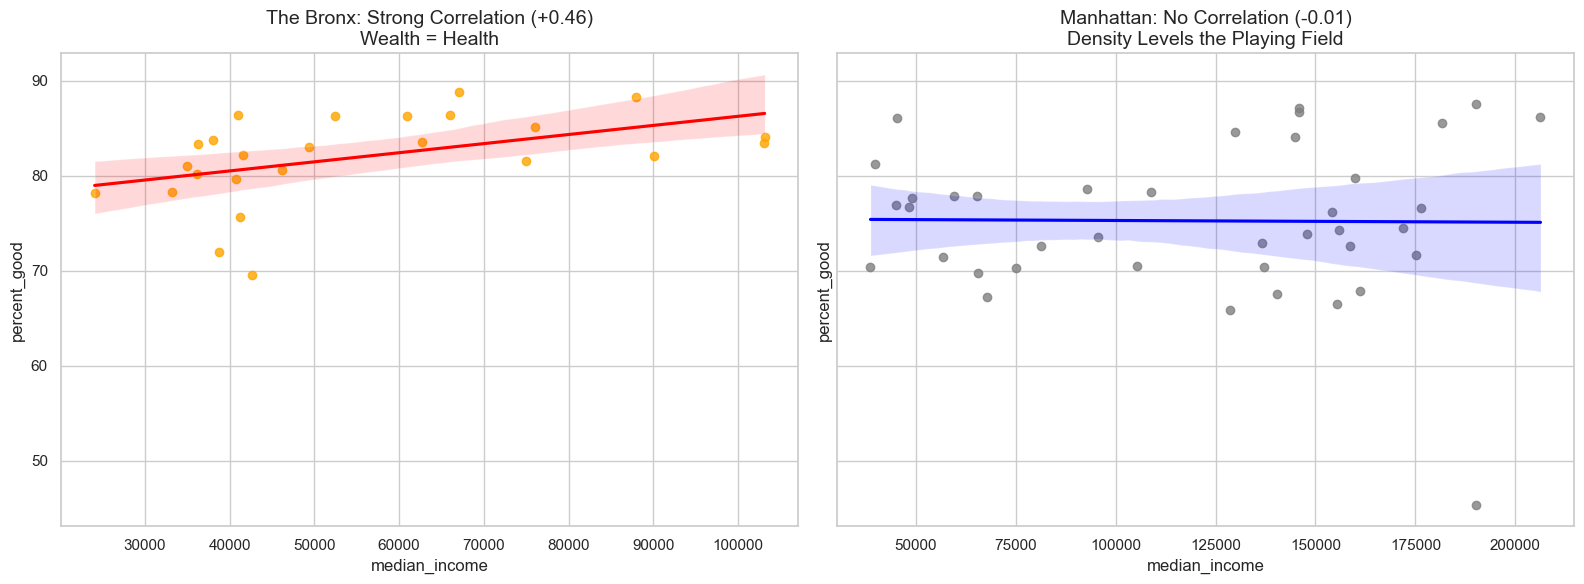

In [13]:
# Create a side-by-side comparison of the Bronx and Manhattan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: The Bronx (The Strong Link)
bronx_data = clean_df[clean_df['borough'] == 'Bronx']
sns.regplot(data=bronx_data, x='median_income', y='percent_good', 
            ax=ax1, color='orange', line_kws={'color':'red'})
ax1.set_title(f'The Bronx: Strong Correlation (+0.46)\nWealth = Health', fontsize=14)

# Plot 2: Manhattan (The Concrete Jungle)
manhattan_data = clean_df[clean_df['borough'] == 'Manhattan']
sns.regplot(data=manhattan_data, x='median_income', y='percent_good', 
            ax=ax2, color='gray', line_kws={'color':'blue'})
ax2.set_title(f'Manhattan: No Correlation (-0.01)\nDensity Levels the Playing Field', fontsize=14)

plt.tight_layout()
plt.show()